In [1]:
from src.instance_generator import InstanceGenerator
import pandas as pd
import seaborn as sns
from pprint import pprint
import pickle
import osmnx as ox
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

sns.set_theme(context='paper', style='darkgrid')
INDO_CRS = "EPSG:23867"

In [2]:
farmers_df = pd.read_csv('data/farmers.csv')
ints_df = pd.read_csv('data/ints.csv')
mills_df  = pd.read_csv('data/mills.csv')

with open("../FactoredPlatformSolver/data/graph_0-14960_00.pickle", 'rb') as pickle_file:
    G = pickle.load(pickle_file)

G = ox.project_graph(G, to_crs=INDO_CRS)

/var/folders/7_/y4vpj6ln7b90djzq_hscbgyr0000gn/T/ipykernel_66666/4205216998.py:6: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  G = pickle.load(pickle_file)


### How many farmers are in each intermediary's network?

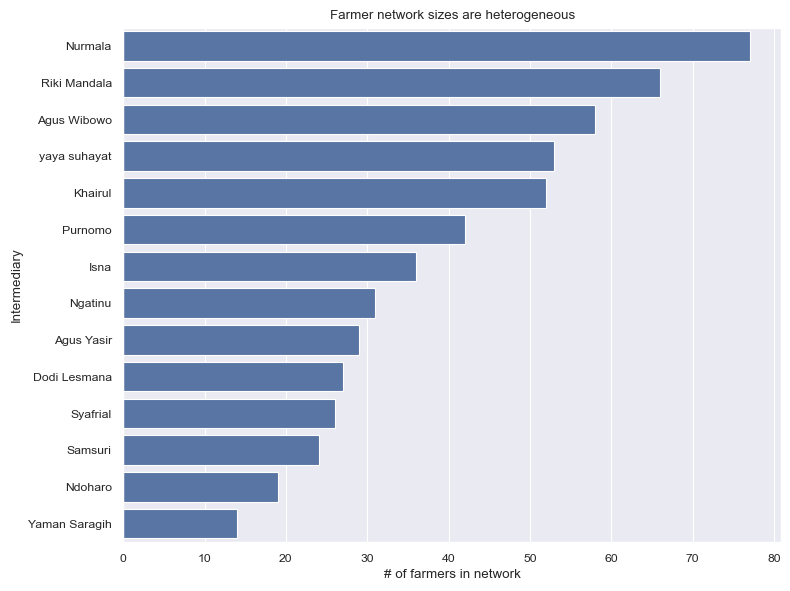

In [3]:
df_1 = farmers_df.copy()
res_1 = df_1.drop_duplicates(['int_id', 'farmer_x', 'farmer_y']).groupby('int_id').size()
res_1.sort_values(inplace=True, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=res_1.values, y=res_1.index)

plt.ylabel('Intermediary')
plt.xlabel('# of farmers in network')
plt.title('Farmer network sizes are heterogeneous')

plt.tight_layout()
plt.show()

### How much do farmers in each intermediary's network produce?

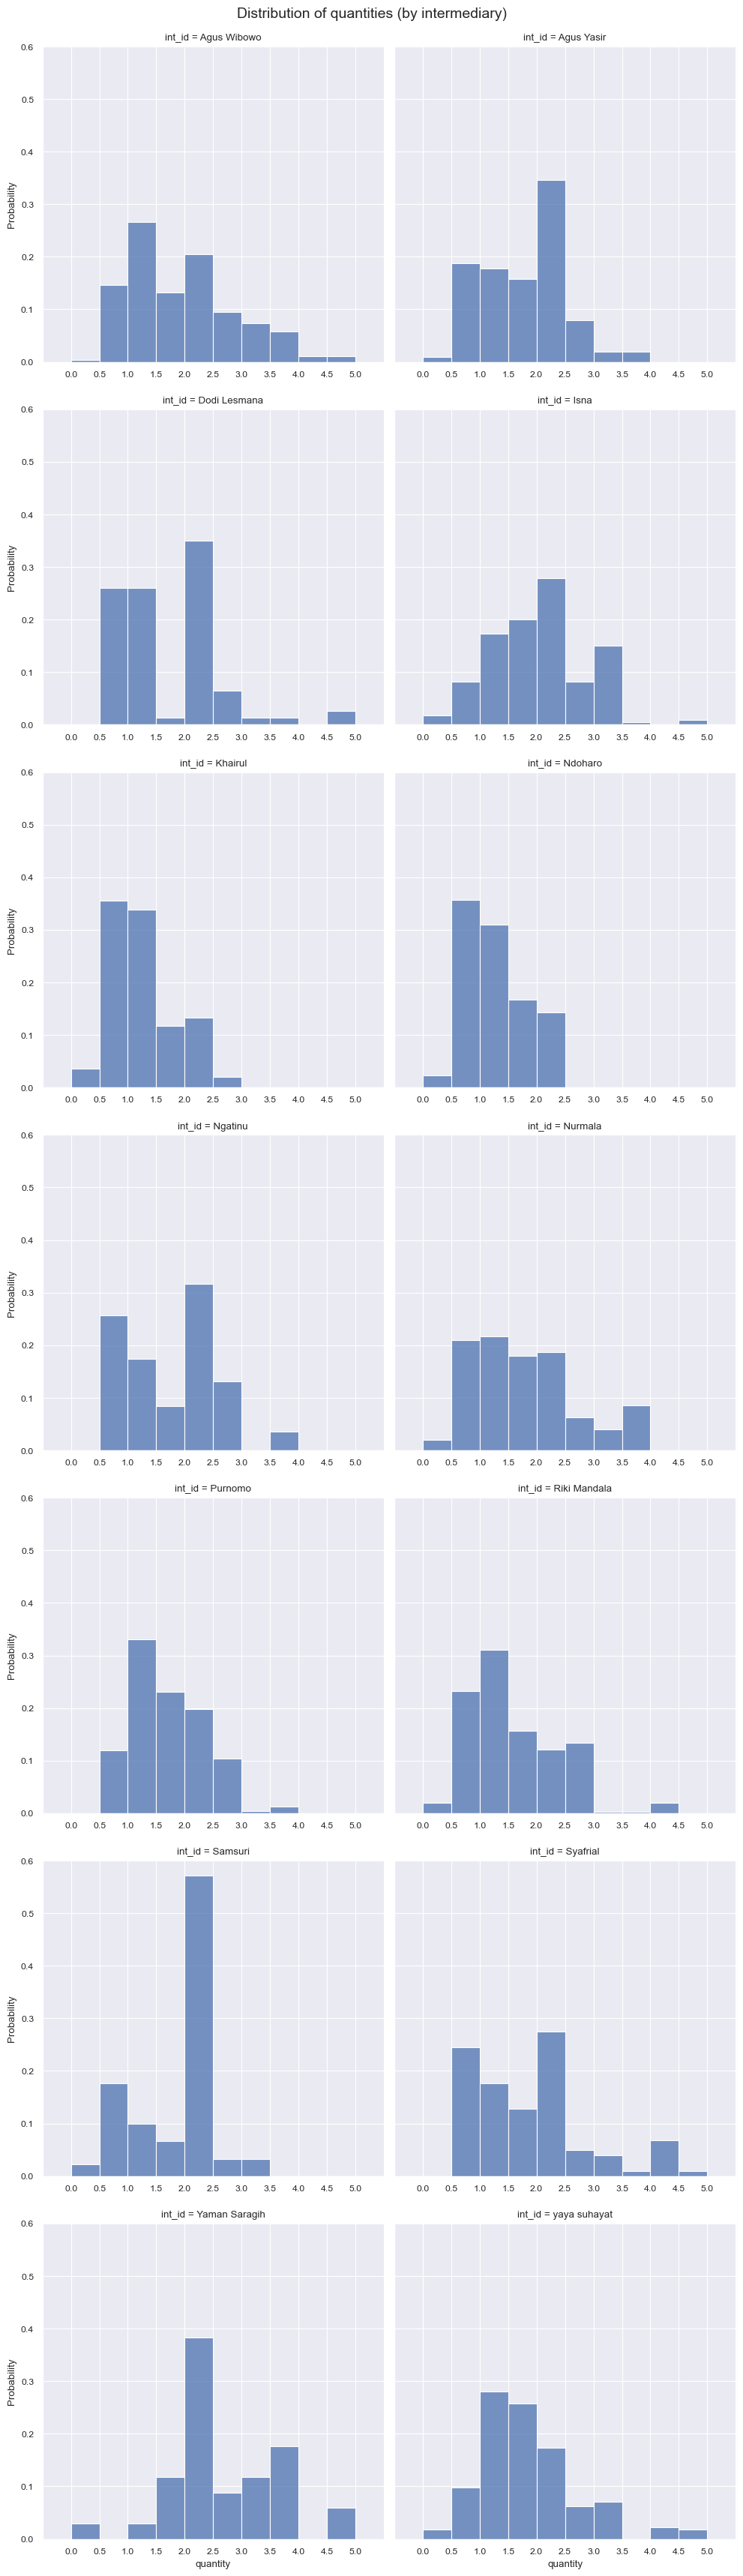

In [4]:
df_2 = farmers_df.copy().sort_values(by='int_id')

bins = np.arange(-0.5, df_2['quantity'].max() + 1.5, 0.5)

g = sns.displot(
    data=df_2,
    x='quantity',
    col='int_id',
    col_wrap=2,
    bins=bins,
    stat='probability',
    common_norm=False,    
    facet_kws={
        'sharex': True,
        'sharey': True
    }
)

xticks = np.arange(0, df_2['quantity'].max() + 1, 0.5)

for ax in g.axes.flatten():
    ax.set_xticks(xticks)
    ax.set_xlim(-0.5, xticks.max() + 0.5)
    ax.tick_params(labelbottom=True)

g.set(ylim=(0, 0.6))
g.figure.suptitle('Distribution of quantities (by intermediary)', fontsize=14)
g.figure.subplots_adjust(top=0.965)

g.figure.subplots_adjust(hspace=0.15)
plt.show()

### Are pickups once every two weeks?

In [5]:
df_3 = farmers_df.copy()
df_3['date'] = pd.to_datetime(df_3['date'])
df_3.sort_values(['int_id', 'farmer_x', 'farmer_y', 'date'], inplace=True)

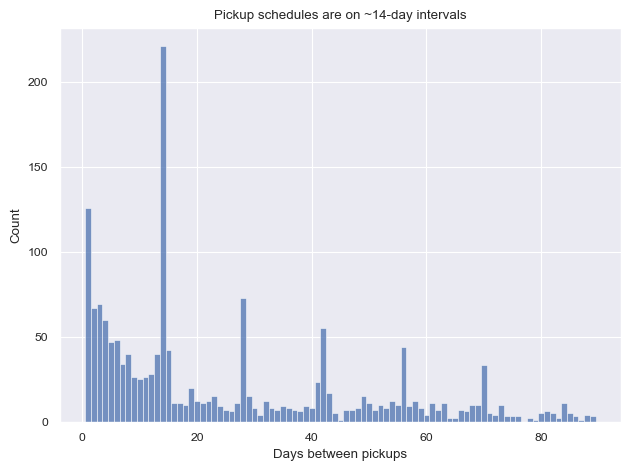

In [6]:
delta_series = (
    df_3.groupby(['int_id', 'farmer_x', 'farmer_y'])['date']
    .diff()
    .dt.days
)

delta_series = delta_series[(delta_series < 90) & (delta_series > 0)]

sns.histplot(delta_series.dropna(), discrete=True)

plt.xlabel('Days between pickups')
plt.title('Pickup schedules are on ~14-day intervals')

plt.tight_layout()
plt.show()

In [7]:
def compute_perturbations(group, period=14):
    dates = group['date'].values.astype('datetime64[D]')
    t = (dates - dates[0]).astype(int)

    # estimate cycle indices
    n = np.round(t / period).astype(int)

    # compute phase: t = phi + 14n -> phi = t - 14n
    phi = int(np.round(np.median(t - period * n)))

    # compute perturbation
    epsilon = t - (phi + period * n)
    out = group.copy()
    out['epsilon'] = epsilon
    return out

res_3 = (
    df_3
    .groupby(['int_id', 'farmer_x', 'farmer_y'], group_keys=True)
    .apply(compute_perturbations)
)

print(f'80th percentile: {int(np.abs(res_3['epsilon']).quantile(0.8))}')
print(f'90th percentile: {int(np.abs(res_3['epsilon']).quantile(0.9))}')
print(f'95th percentile: {int(np.abs(res_3['epsilon']).quantile(0.95))}')

80th percentile: 3
90th percentile: 5
95th percentile: 6


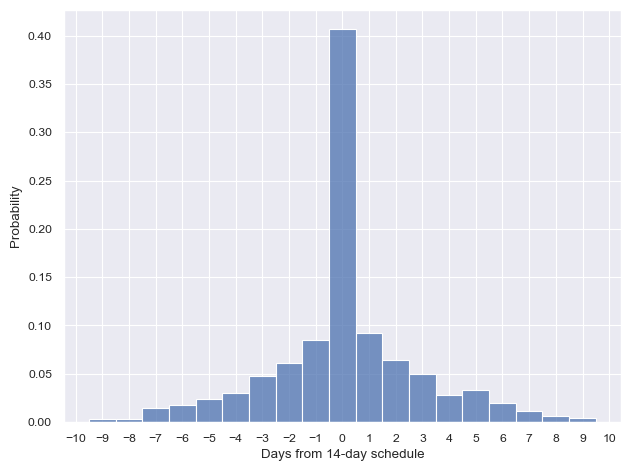

In [8]:
eps = res_3['epsilon']
eps = eps[(eps > -10) & (eps < 10)]

sns.histplot(eps, bins=20, discrete=True, stat='probability')

xticks = np.arange(-10, 10 + 1, 1)

plt.xlabel('Days from 14-day schedule')
plt.xticks(xticks)
# plt.title('Most pickups are within 3 days of 14 day schedule')

plt.tight_layout()
plt.show()

### 3. How many farmers do intermediaries pick up from daily?

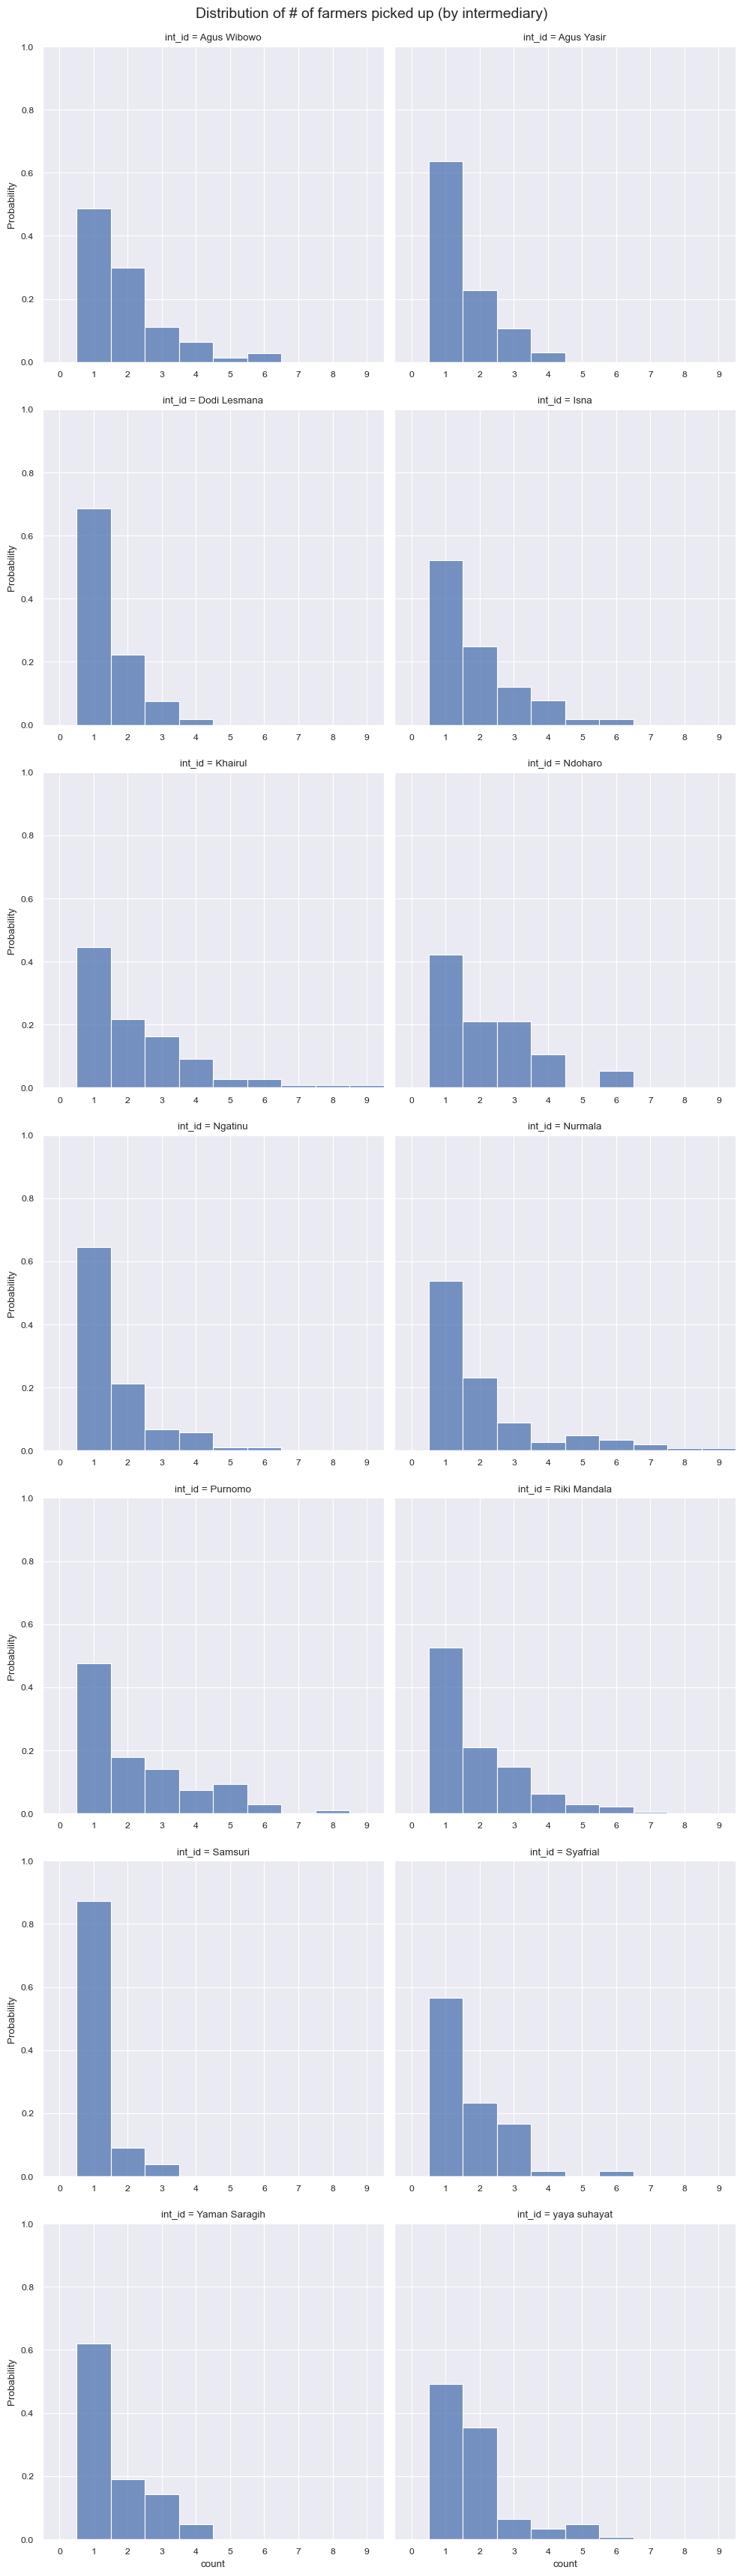

In [9]:
df_4 = (
    farmers_df
    .groupby(['int_id', 'date'])
    .size())

df_4 = df_4.reset_index(name='count')

bins = np.arange(-0.5, df_4['count'].max() + 1.5, 1)

g = sns.displot(
    data=df_4,
    x='count',
    col='int_id',
    col_wrap=2,
    bins=bins,
    discrete=True,
    stat='probability',
    common_norm=False,     # critical for fair comparison
    facet_kws={
        'sharex': True,
        'sharey': True
    }
)

xticks = np.arange(0, df_4['count'].max() + 1)

for ax in g.axes.flatten():
    ax.set_xticks(xticks)
    ax.set_xlim(-0.5, xticks.max() + 0.5)
    ax.tick_params(labelbottom=True)

g.set(ylim=(0, 1))

g.figure.suptitle('Distribution of # of farmers picked up (by intermediary)', fontsize=14)
g.figure.subplots_adjust(top=0.965)
g.figure.subplots_adjust(hspace=0.15)

plt.show()

### How far are pickups from each other on the same date?

In [10]:
G_proj = ox.project_graph(G, to_crs=INDO_CRS)

df_5 = farmers_df.copy()

df_5['node_id'] = ox.nearest_nodes(G_proj, df_5.farmer_x, df_5.farmer_y)

def solve_road_tsp(group, graph):
    """
    Calculates the shortest road path to visit all unique nodes in a group.
    """
    nodes = group['node_id'].dropna().unique().tolist()
    
    if len(nodes) < 2:
        return 0.0
    
    dist_matrix = {}
    for u in nodes:
        if u not in graph: continue
        lengths = nx.multi_source_dijkstra_path_length(graph, {u}, weight='length')
        dist_matrix[u] = {v: lengths[v] for v in nodes if v in lengths}

    valid_nodes = list(dist_matrix.keys())
    if len(valid_nodes) < 2:
        return 0.0

    TSP_G = nx.Graph()
    for i, u in enumerate(valid_nodes):
        for v in valid_nodes[i+1:]:
            if v in dist_matrix[u]:
                TSP_G.add_edge(u, v, weight=dist_matrix[u][v])

    try:
        tsp_path = nx.approximation.traveling_salesman_problem(TSP_G, cycle=False)
        
        total_road_dist = 0
        for i in range(len(tsp_path) - 1):
            total_road_dist += dist_matrix[tsp_path[i]][tsp_path[i+1]]
        return total_road_dist
    except Exception:
        return -1

daily_road_travel = df_5.groupby(['int_id', 'date']).apply(
    lambda x: solve_road_tsp(x, G_proj), 
    include_groups=False
)

daily_km = daily_road_travel[daily_road_travel > 0] / 1000
print(daily_km.describe())

count    561.000000
mean      13.572670
std       16.746957
min        0.352191
25%        3.756416
50%        7.943098
75%       14.543065
max      102.200068
dtype: float64


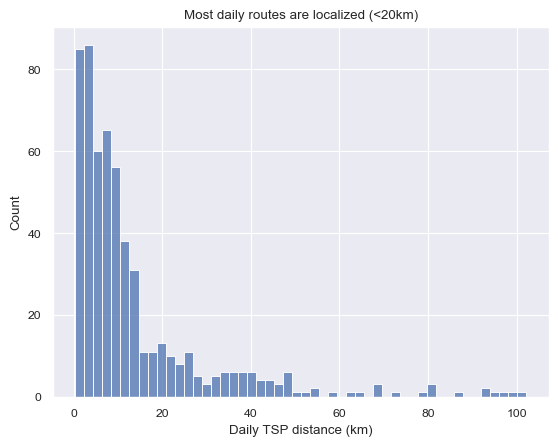

In [35]:
sns.histplot(daily_km, bins=50)
plt.xlabel('Daily TSP distance (km)')
plt.title('Most daily routes are localized (<20km)')
plt.show()

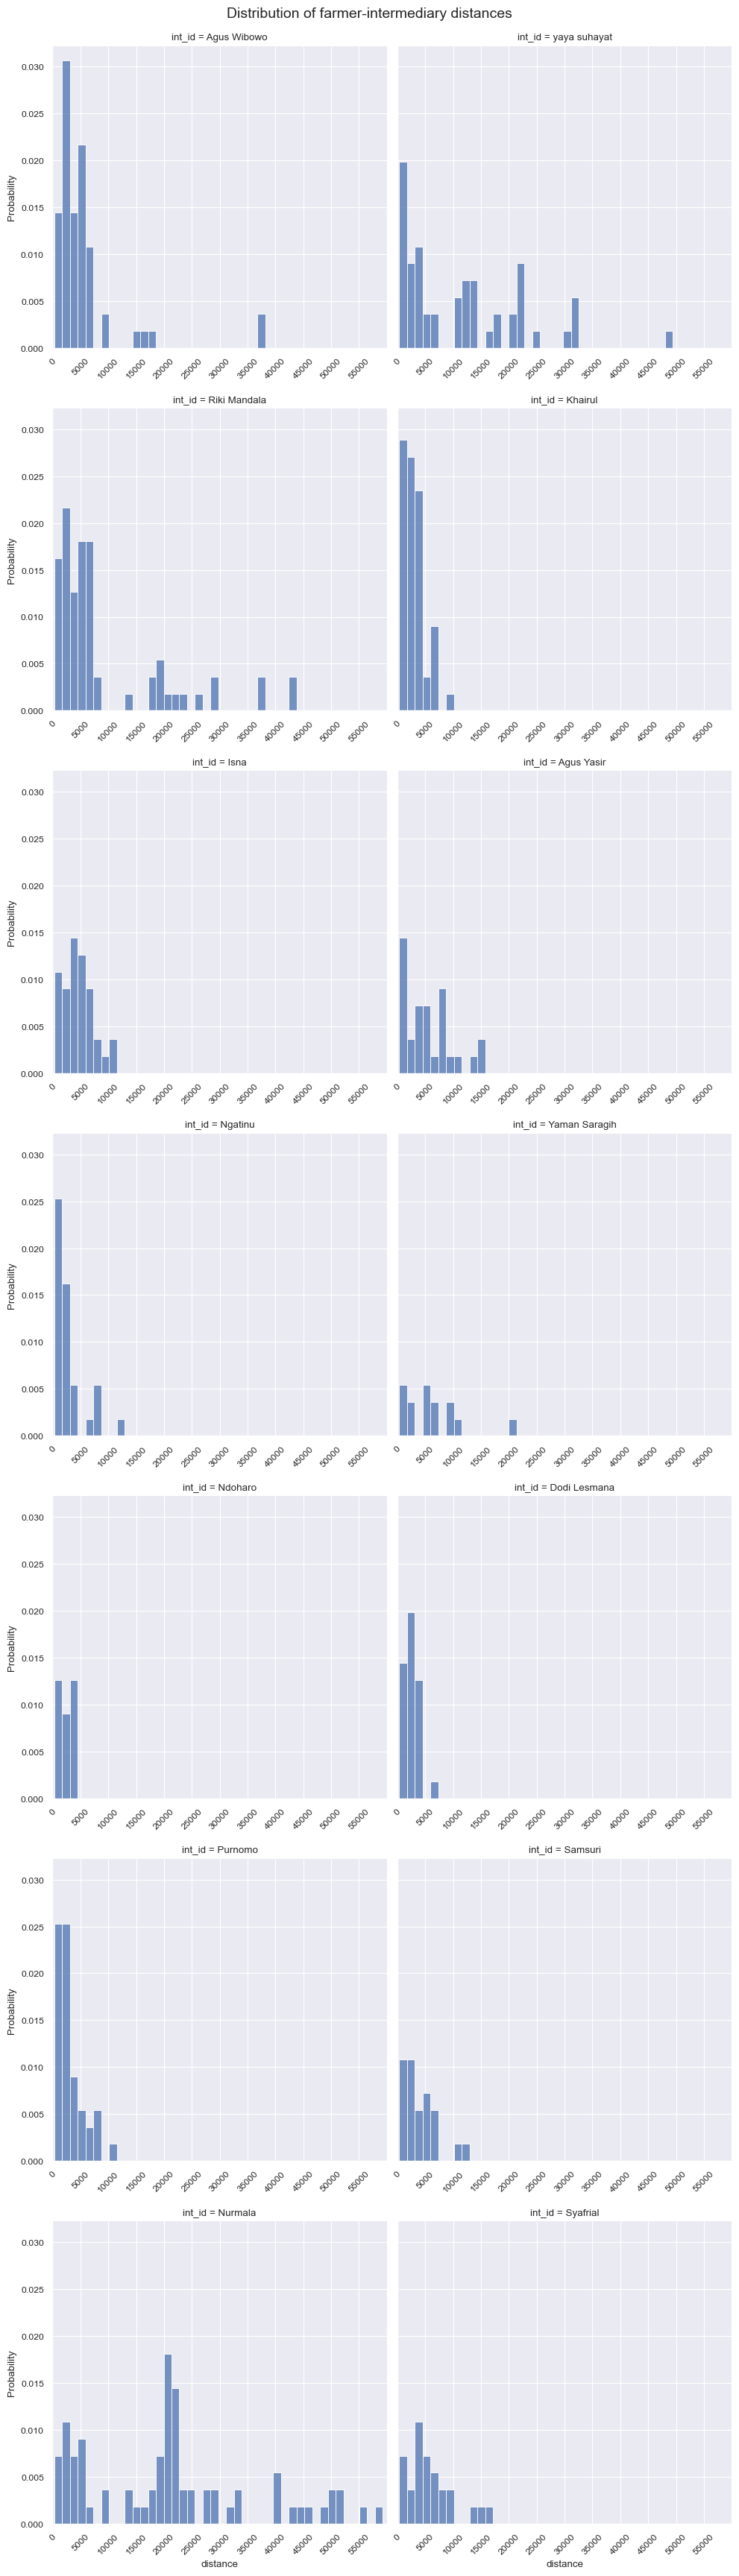

In [36]:
df_6 = farmers_df.copy()

df_6.drop_duplicates(['int_id', 'farmer_x', 'farmer_y'], inplace=True)


g = sns.displot(
    data=df_6,
    x='distance',
    col='int_id',
    col_wrap=2,
    stat='probability',
    facet_kws={
        'sharex': True,
        'sharey': True
    }
)


xticks = np.arange(0, 55000+1, 5000)

for ax in g.axes.flatten():
    ax.set_xticks(xticks)
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_xlim(-0.5, 60000 + 0.5)
    ax.tick_params(labelbottom=True)

g.figure.suptitle('Distribution of farmer-intermediary distances', fontsize=14)
g.figure.subplots_adjust(top=0.965)

g.figure.subplots_adjust(hspace=0.2)

plt.show()